# ENSO longitude index change over time

## Imports

In [1]:
import datetime
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
import xarray as xr
import tqdm
import pathlib
import cmocean
import os
import src.XRO
import copy
import scipy.stats
import warnings
import calendar
import scipy.optimize

## set plotting specs
sns.set(rc={"axes.facecolor": "white", "axes.grid": False}, palette="colorblind")

## bump up DPI
mpl.rcParams["figure.dpi"] = 100

## get filepaths
DATA_FP = pathlib.Path(os.environ["DATA_FP"])
SAVE_FP = pathlib.Path(os.environ["SAVE_FP"])

## RNG
rng = np.random.default_rng()

## Funcs

In [2]:
def get_rolling_std(data, n=20):
    """
    Get standard deviation, computing over time and ensemble member. To increase
    sample size for variance estimate, compute over time window of 2n+1
    years, centered at given year.
    """

    ## do the computation
    kwargs = dict(fn=np.std, n=n, reduce_ensemble_dim=False)
    data_std = src.utils.get_rolling_fn_bymonth(data, **kwargs)

    ## unstack year and month
    data_std = src.utils.unstack_month_and_year(data_std)

    return data_std


def get_stats(x):
    """helper function to compute plotting bounds for experiment"""
    stats = x.quantile(q=[0.1, 0.5, 0.9], dim="member")
    return stats.rename({"quantile": "q"})


def get_fits_over_time(data_rolling, model, by_member=False, **fit_kwargs):
    """Get RO fits for each ensemble member as a function of time."""

    ## empty list to hold results
    fits = []

    ## loop through years
    for y in tqdm.tqdm(data_rolling.year):

        ## get data for year
        data_y = data_rolling.sel(year=y)

        if by_member:

            ## separate fit for each ensemble member
            fits_ = []
            for m in data_rolling.member:
                with warnings.catch_warnings(action="ignore"):
                    fits_.append(model.fit_matrix(data_y.sel(member=m), **fit_kwargs))
            fit = xr.concat(fits_, dim=data_y.member)

        else:

            ## fit for all ensemble members together
            with warnings.catch_warnings(action="ignore"):
                fit = model.fit_matrix(data_y, **fit_kwargs)

        ## track fits
        fits.append(fit.drop_vars(["time", "X", "Y", "Yfit"]))

    ## put back in xarray
    fits = xr.concat(fits, dim=data_rolling.year)

    return fits


def get_fits_over_time_wrapper(
    data_rolling, model, by_member=False, fname=None, **fit_kwargs
):
    """wrapper function to handle saving/loading"""

    ## function to compute fits
    get_fits = lambda: get_fits_over_time(
        data_rolling, model=model, by_member=by_member, **fit_kwargs
    )

    ## if fname not specified, compute without loading/saving
    if fname is None:
        fits = get_fits()

    else:

        ## get full filepath
        fp = pathlib.Path(os.environ["SAVE_FP"], "fits_cesm", fname)

        ## try to load pre-computed
        if fp.is_file():
            print("Loading pre-computed")
            fits = xr.open_dataset(fp)

        ## otherwise, compute and save
        else:
            fits = get_fits()
            fits.to_netcdf(fp)

    return fits


def save(fig, fname, dpi=300):
    """save figure to file"""

    ## get save directory
    save_dir = pathlib.Path(os.environ["SAVE_FP"], "ch3-outline")

    ## get fname
    fname = save_dir / f"{fname}.pdf"

    fig.savefig(fname, dpi=dpi)


def get_RO_sigma(model, params, **simulation_kwargs):
    """Compute stats (e.g., standard deviation) for RO parameters over time"""

    output = model.simulate(fit_ds=params, **simulation_kwargs)

    return output.groupby("time.month").std()


def get_RO_sigma_over_time(model, params, **simulation_kwargs):
    """Compute stats over time"""

    ## take ensemble mean if necessary
    if "member" in params.dims:
        params = params.mean("member")

    ## empty list to hold result
    sigmas = []

    ## loop through years
    for y in tqdm.tqdm(params.year):

        ## specs for simulation
        kwargs = dict(
            simulation_kwargs,
            model=model,
            params=params.sel(year=y),
        )

        ## do the simulation
        sigmas.append(get_RO_sigma(**kwargs))

    ## put back in xarray
    sigmas = xr.concat(sigmas, dim=params.year)

    return sigmas


def plot_stats_comp(ax, list_of_stats, labels, n, colors=None):
    """plot comparison of variance over time"""

    if colors is None:
        colors = sns.color_palette()[: len(list_of_stats)]

    for stats, label, c in zip(list_of_stats, labels, colors):

        ## plot median
        mplot = ax.plot(stats.year, stats[n].sel(q=0.5), lw=2.5, label=label, c=c)

        ## plot lower/upper quantiles
        kwargs = dict(c=mplot[0].get_color(), lw=0.8)
        for q in stats.q:
            if q != 0.5:
                ax.plot(stats.year, stats[n].sel(q=q), **kwargs)

    ## label and set plotting specs
    ax.set_xlabel("Year")
    ax.set_ylabel(r"$\sigma_T$ ($^{\circ}$C)")
    ax.set_ylim([0.3, 1.7])
    ax.set_xticks([1870, 1975, 2080])
    ax.set_yticks([0.6, 1.2])

    return


def format_validation_plots(axs):
    """add formatting to CESM v. RO plot"""

    axs[1, 0].set_ylabel(r"$\sigma_h$($^{\circ}$C)")
    axs[0, 1].legend(prop=dict(size=8))
    for i in range(axs.shape[1]):
        ## remove ticks
        axs[0, i].set_xticks([])
        axs[0, i].set_xlabel(None)
        if i > 0:
            for ax in axs[:, i]:
                ax.set_yticks([])
                ax.set_ylabel(None)

    return

## Load data

### T, h

In [3]:
## open data
Th = src.utils.load_cesm_indices(load_z20=True, load_h_cust=True, max_grad=True)

## omit first year (bc of NaN in h,hw vars)
Th = Th.sel(time=slice("1851", None))

## Load ELI
eli = xr.open_dataset(pathlib.Path(DATA_FP, "cesm/eli.nc"))
eli_forced, eli_anom = src.utils.separate_forced(eli)

## merge
Th = xr.merge([Th, eli_anom.sel(time=slice("1851", None))])
eli_forced = eli_forced.sel(time=slice("1851", None))

### preprocess

In [4]:
## standardize (for convenience)
Th_scale = Th.std()
Th /= Th_scale

## get windowed data (used to estimate change in parameters over time)
Th_rolling = src.utils.get_windowed(Th, window_size=480, stride=120)
eli_forced = src.utils.get_windowed(eli_forced, window_size=480, stride=120)

## compute grad
Th_rolling["dTdx"] = Th_rolling["T_3"] - Th_rolling["T_4"]

#### Scale by $\overline{h}$

In [5]:
hbar_scale = xr.open_dataarray(
    pathlib.Path(SAVE_FP, "cesm_Hbar_scale.nc"),
)
# Th_rolling["h_w_Hbar-scaled"] = Th_rolling["h_w"] * hbar_scale
Th_rolling["h_w_Hbar-scaled"] = Th_rolling["h_w"] * hbar_scale

#### Scale ELI by $dT/dx$

In [6]:
## load dT/dx data
# dTdx = xr.open_dataarray(pathlib.Path(SAVE_FP, "cesm_dTdx.nc"))
dTdx = xr.open_dataarray(pathlib.Path(SAVE_FP, "cesm_dTdx_Tw.nc"))

## scale by initial value
dTdx_scale = dTdx / dTdx.isel(year=0).mean(["month"])

for v in list(Th_rolling):
    if "eli" in v:
        Th_rolling[f"{v}_scaled"] = Th_rolling[v].groupby("time.month") * dTdx_scale

        ## subtrack median
        grouped = Th_rolling[f"{v}_scaled"].groupby("time.month")
        Th_rolling[f"{v}_scaled_median"] = grouped - grouped.median(["member", "time"])

## Fit RO

### Do fitting

In [28]:
## specify filename for saving (if None, then don't save/load)
FNAME = "eli_05_scaled_Tw_h_w_Hbar_real_nl_T3"
# FNAME = "eli_10_scaled_median_h_w_Hbar_real_nl"

## should we use forward differences to estimate operator?
IS_FORWARD = True

## specify variables
varnames = ["eli_05_scaled_median", "h_w_Hbar-scaled"]

## fit for each ensemble member differently
BY_MEMBER = False

## parameters for fitting
MODEL = src.XRO.XRO(ncycle=12, ac_order=3, is_forward=IS_FORWARD)
fit_kwargs = dict(ac_mask_idx=None, maskNT=["T2", "T3"])
# fit_kwargs = dict(ac_mask_idx=None, maskNT=[])

## get fits
fits = get_fits_over_time_wrapper(
    Th_rolling[varnames],
    model=MODEL,
    by_member=BY_MEMBER,
    fname=FNAME,
    **fit_kwargs,
)

## extract parameters
params = src.utils.get_params(fits=fits, model=MODEL)

## get change from initial period
delta_params = params - params.isel(year=0)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:06<00:00,  3.32it/s]


### Stochastic integration

In [29]:
## should we use noise covariance
# USE_NOISE_COV = False
USE_NOISE_COV = True

## simulation specs
simulation_kwargs = dict(
    nyear=40,
    ncopy=50,
    seed=1000,
    X0_ds=Th_rolling[varnames].isel(year=0, member=0, time=0),
    noise_type="white",
    use_noise_cov=USE_NOISE_COV,
    is_xi_stdac=True,
)

## compute with parameters estimated from all ensemble members
RO_sigma_over_time_v2 = get_RO_sigma_over_time(
    model=MODEL, params=fits, **simulation_kwargs
)

  0%|                                                                                                                                                                                | 0/22 [00:00<?, ?it/s]/Users/theo/research/enso2025_xro/src/XRO.py:1233: RuntimeWarning: overflow encountered in square
  b[:, None] * X**2
/Users/theo/research/enso2025_xro/src/XRO.py:1233: RuntimeWarning: invalid value encountered in multiply
  b[:, None] * X**2
/Users/theo/research/enso2025_xro/src/XRO.py:1234: RuntimeWarning: overflow encountered in power
  + c[:, None] * X**3
/Users/theo/research/enso2025_xro/src/XRO.py:1234: RuntimeWarning: invalid value encountered in multiply
  + c[:, None] * X**3
/Users/theo/research/enso2025_xro/src/XRO.py:1600: RuntimeWarning: overflow encountered in multiply
  RO_T2 = X[0,] * X[0,]
/Users/theo/research/enso2025_xro/src/XRO.py:1602: RuntimeWarning: overflow encountered in multiply
  RO_T3 = X[0,] * X[0,] * X[0,]
/Users/theo/research/enso2025_xro/src/XRO.py:1603: 

### Compute stats / validate

#### Stats

In [30]:
## compute rolling std
# Th_std = get_rolling_std(Th, n=20)
Th_std = Th_rolling.groupby("time.month").std("time")

## compute percentage change in std
baseline = Th_std.isel(year=0).mean("member")
delta_Th_std = 100 * (Th_std - baseline) / baseline

#### Plot ELI variance

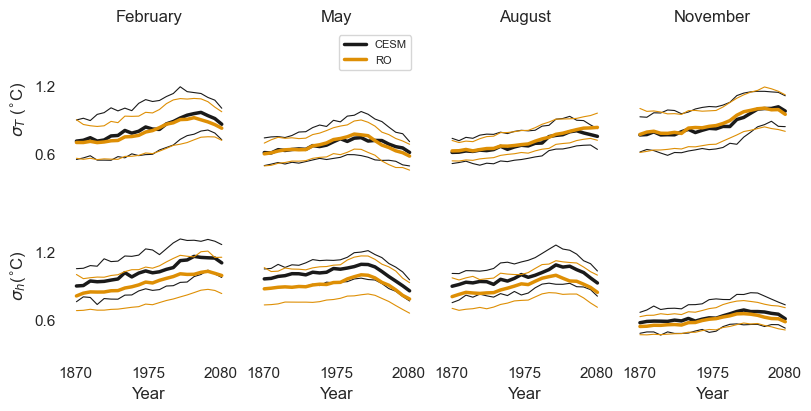

In [31]:
## specify months to plot
PLOT_MONTHS = [2, 5, 8, 11]

fig, axs = plt.subplots(2, 4, figsize=(8, 4), layout="constrained")

for i, m in enumerate(PLOT_MONTHS):

    ## compute stats
    stats_mpi = get_stats(Th_std).sel(month=m)
    stats_ro_v2 = get_stats(RO_sigma_over_time_v2).sel(month=m)

    ## specify kwargs
    plot_kwargs = dict(
        list_of_stats=[stats_mpi, stats_ro_v2],
        labels=["CESM", "RO"],
        colors=["k", sns.color_palette()[1]],
    )

    ## plot comparison
    for j, ax in enumerate(axs[:, i]):
        plot_stats_comp(ax, n=varnames[j], **plot_kwargs)

    ## label
    axs[0, i].set_title(calendar.month_name[m])

## format all subplots
format_validation_plots(axs)

plt.show()

#### helper funcs to obtain transfer func

In [11]:
def psi_(x, a, b, c):
    """base transfer function"""
    return c * np.exp(a * x) + b


def get_psi(x, y):
    """get transfer function from data"""

    ## get parameter fit
    p, _ = scipy.optimize.curve_fit(
        f=psi_, xdata=x.values, ydata=y.values, p0=[-1, 1, -1]
    )

    ## define transfer func
    psi = lambda x: psi_(x, a=p[0], b=p[1], c=p[2])

    return psi

#### Compute time-varying transfer func

In [12]:
## specify data to fit to
V0 = varnames[0]

## empty arrays to hold time- and seasonally-varying basis functions
psi_T3 = np.empty(shape=(len(Th_rolling.year), 12), dtype="object")
psi_T34 = copy.deepcopy(psi_T3)
psi_T4 = copy.deepcopy(psi_T3)

## function to stack data
stack = lambda x: x.stack(s=["time", "member"])

## loop through years and months
for yi, year in enumerate(Th_rolling.year.values):
    for mi, month in enumerate(np.arange(1, 13)):

        ## get subset of data
        data_ = stack(src.utils.sel_month(Th_rolling.sel(year=year), month.item()))

        for v, psi_mat in zip(["T_3", "T_34", "T_4"], [psi_T3, psi_T34, psi_T4]):

            ## select data
            x = data_[V0]
            y = data_[v]

            ## get best fit
            try:
                ## compute
                psi_mat[yi, mi] = get_psi(x=data_[V0], y=data_[v])

            except:
                psi_mat[yi, mi] = np.nan

In [13]:
# psi_xr = xr.DataArray(
#     psi_mat,
#     dims=["year", "month"],
#     coords=dict(year=Th_rolling.year.values, month=np.arange(1,13))
# )

#### Plot

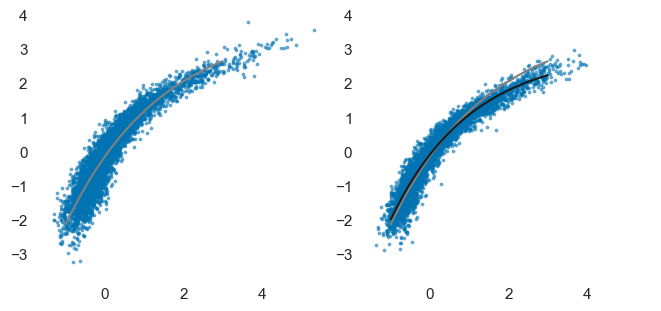

In [14]:
## specify month
MONTH = 2

## specify years
# Y0 = 1871
# Y1 = 2031
Y0 = 2001
Y1 = 2071

## specify variables to use and associated transfer func
V0 = varnames[0]
V1, PSI = "T_3", psi_T34

## select data
# sel = lambda x: src.utils.sel_month(x, MONTH).stack(s=["member", "time"])
# sel = lambda x: src.utils.sel_month(x, [12,1,2]).stack(s=["member", "time"])
sel = lambda x: src.utils.sel_month(x.resample({"time": "QS-DEC"}).mean(), 12).stack(
    s=["member", "time"]
)
x = sel(Th_rolling[V0])
# x = sel(Th_rolling["eli_15_scaled_median"])
y = sel(Th_rolling[V1])

## Get month index
MONTH_IDX = MONTH - 1

## plot
fig, axs = plt.subplots(1, 2, figsize=(6.5, 3), layout="constrained")

## plot data
axs[0].scatter(
    x.sel(year=Y0),
    y.sel(year=Y0),
    s=3,
    alpha=0.5,
)

axs[1].scatter(
    x.sel(year=Y1),
    y.sel(year=Y1),
    s=3,
    alpha=0.5,
)

## get best fit
psi0 = get_psi(x.sel(year=Y0), y.sel(year=Y0))
psi1 = get_psi(x.sel(year=Y1), y.sel(year=Y1))

## plot best fits
zz = np.linspace(-1, 3)
# axs[0].plot(zz, PSI[0, MONTH_IDX](zz), c="gray")
# axs[1].plot(zz, PSI[0, MONTH_IDX](zz), c="gray")
# axs[1].plot(zz, PSI[-1, MONTH_IDX](zz), c="k")
axs[0].plot(zz, psi0(zz), c="gray")
axs[1].plot(zz, psi0(zz), c="gray")
axs[1].plot(zz, psi1(zz), c="k")


src.utils.set_lims(axs)

plt.show()

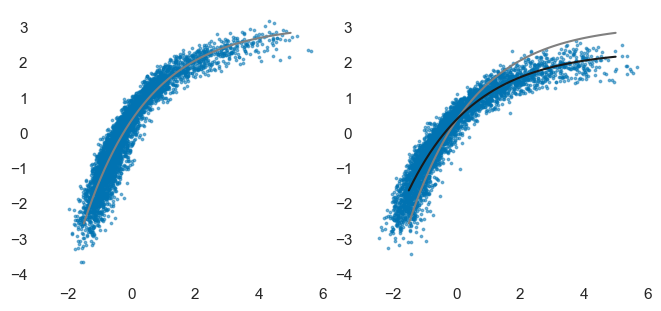

In [15]:
## specify years
# Y0 = 1871
# Y1 = 2031
Y0 = 2031
Y1 = 2071

sel_djf = lambda x: x.sel(month=[12, 1, 2]).mean("month")
sel_mam = lambda x: x.sel(month=[3, 4, 5]).mean("month")
sel_ = sel_djf
dTdx_ratio = sel_(dTdx).sel(year=Y1) / sel_(dTdx).sel(year=Y0)

## specify variables to use and associated transfer func
V0 = varnames[0]
V1 = "T_34"

## select data
sel = lambda x: src.utils.sel_month(x.resample({"time": "QS-DEC"}).mean(), 12).stack(
    s=["member", "time"]
)
x = sel(Th_rolling["eli_05"])
y = sel(Th_rolling[V1])

## plot
fig, axs = plt.subplots(1, 2, figsize=(6.5, 3), layout="constrained")

## plot data
axs[0].scatter(
    x.sel(year=Y0),
    y.sel(year=Y0),
    s=3,
    alpha=0.5,
)

axs[1].scatter(
    x.sel(year=Y1),
    y.sel(year=Y1),
    s=3,
    alpha=0.5,
)

## get best fit
psi0 = get_psi(x.sel(year=Y0), y.sel(year=Y0))
psi1 = get_psi(x.sel(year=Y1), y.sel(year=Y1))

## plot best fits
zz = np.linspace(-1.5, 5)
axs[0].plot(zz, psi0(zz), c="gray")
axs[1].plot(zz, psi0(zz), c="gray")
# axs[1].plot(zz, psi0(zz) * dTdx_ratio.item(), c="gray")
axs[1].plot(zz, psi1(zz), c="k")


src.utils.set_lims(axs)

plt.show()

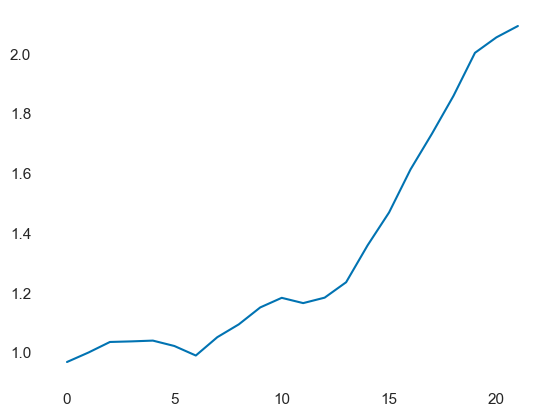

In [16]:
plt.plot(
    src.utils.sel_month(
        Th_rolling["eli_05"].resample({"time": "QS-DEC"}).mean(), 12
    ).quantile(q=0.9, dim=["member", "time"])
)

#### Reconstruct from scaled ELI over time

Compare Jan ELI and $T_{34}$

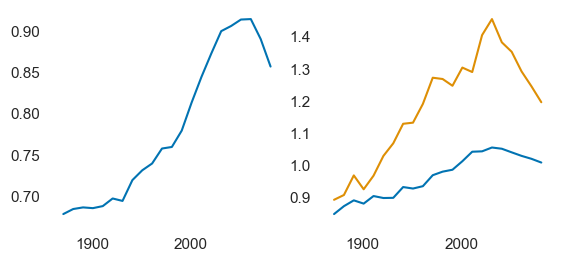

In [17]:
## specify month
MONTH = 2

## specify variable and transfer func
V1, PSI = "T_3", psi_T3
# V1, PSI = "T_34", psi_T34
# V1, PSI = "T_4", psi_T4

## funcs to select data
sel = lambda x: src.utils.sel_month(x, MONTH)
MONTH_IDX = MONTH - 1

## compute stats
stats_mpi = get_stats(Th_std).sel(month=MONTH)
stats_ro_v2 = get_stats(RO_sigma_over_time_v2).sel(month=MONTH)

## compute reconstructed sigma
sigma_recon = np.zeros(len(Th_rolling.year))

# v1: based on true ELI dist
for yi, y in enumerate(Th_rolling.year.values):
    #     sigma_recon[yi] = np.std(
    #         PSI[yi, MONTH_IDX](
    #             sel(Th_rolling["eli_05_scaled"].isel(year=yi)),
    #         )
    #     )

    # v2: based on normal ELI
    eli_rand = rng.normal(
        size=10000,
        scale=stats_mpi[V0].isel(q=1).sel(year=y),
    )
    sigma_recon[yi] = np.std(PSI[yi, MONTH_IDX](eli_rand))

sigma_recon = xr.DataArray(sigma_recon, coords=dict(year=Th_rolling.year.values))

########

## function to get difference
# diff = lambda x: x - x.isel(year=0)
diff = lambda x: x

## plot
fig, axs = plt.subplots(1, 2, figsize=(5.5, 2.5), layout="constrained")

axs[0].plot(
    stats_ro_v2.year,
    stats_ro_v2[V0].sel(q=0.5),
)

axs[1].plot(
    stats_mpi.year,
    diff(stats_mpi[V1].sel(q=0.5)),
)

axs[1].plot(
    stats_mpi.year,
    diff(sigma_recon),
)

## power transform stuff

In [18]:
from sklearn.preprocessing import PowerTransformer


## helper function to fit a pt
def fit_pt(z, get_lambda=False):
    """fit power transform to data"""
    if np.isnan(z).all():
        return np.nan

    else:
        ## fit transform
        pt = PowerTransformer(standardize=True).fit(z[:, None])

        if get_lambda:
            return pt, pt.lambdas_.item()

        else:
            return pt


def fit_transform_pt(z, get_lambda=False):
    """fit power transform to data"""
    if np.isnan(z).all():
        return np.nan

    else:
        ## fit transform
        pt = PowerTransformer(standardize=True).fit(z[:, None])

        ## apply transform
        return pt.transform(z[:, None]).flatten()

In [19]:
sel_ = lambda x: stack(src.utils.sel_month(x, 1))
# sel = lambda x : sel_(x) - sel_(x).median()
sel = lambda x: sel_(x)

Y_ = Y0
x_ = sel(Th_rolling["eli_15_scaled_median"].sel(year=Y_)).values
T34 = sel(Th_rolling["T_34"].sel(year=Y_)).values
T3 = sel(Th_rolling["T_3"].sel(year=Y_)).values
T4 = sel(Th_rolling["T_4"].sel(year=Y_)).values

## transform it
pt, lam = fit_pt(x_, get_lambda=True)
y = pt.transform(x_[:, None]).flatten()

## compute skew
sx = scipy.stats.skew(x_)
sy = scipy.stats.skew(y)

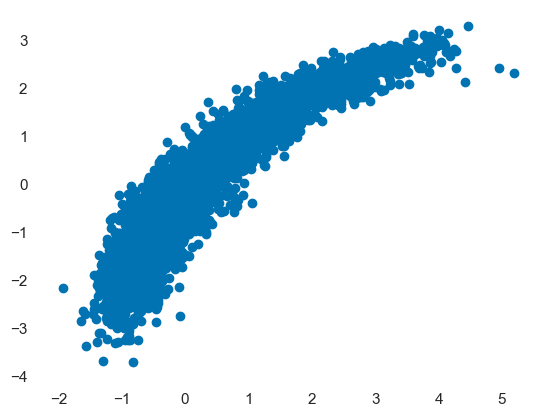

In [20]:
plt.scatter(x_, T34)
# plt.scatter(y, T4)
# plt.hist(x_)
# plt.hist(y, bins=20)
# plt.scatter(y, T34)

median:
0.00
0.00

std dev:


/Users/theo/research/enso2025_xro/src/XRO.py:1234: RuntimeWarning: overflow encountered in power
  + c[:, None] * X**3
/Users/theo/research/enso2025_xro/src/XRO.py:1234: RuntimeWarning: invalid value encountered in multiply
  + c[:, None] * X**3
/Users/theo/research/enso2025_xro/src/XRO.py:1602: RuntimeWarning: overflow encountered in multiply
  RO_T3 = X[0,] * X[0,] * X[0,]
/Users/theo/research/enso2025_xro/src/XRO.py:1603: RuntimeWarning: overflow encountered in multiply
  RO_T2H = X[0,] * X[0,] * X[1,]
/Users/theo/research/enso2025_xro/src/XRO.py:1606: RuntimeWarning: invalid value encountered in matmul
  tend_nro[rank] = NRO @ X_NRO


1.23
1.24


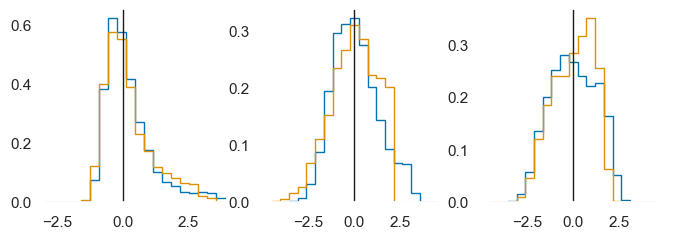

In [21]:
stack = lambda x: x.stack(s=["time", "member"])

# Y0 = 1871
# Y1 = 2031
Y0 = 2031
Y1 = 2071
stoc0 = MODEL.simulate(fit_ds=fits.sel(year=Y0), **simulation_kwargs)
stoc1 = MODEL.simulate(fit_ds=fits.sel(year=Y1), **simulation_kwargs)


# sel_ = lambda x : stack(src.utils.sel_month(x,1))
sel_ = lambda x: stack(src.utils.sel_month(x, 2))
# sel = lambda x : sel_(x) - sel_(x).median()
sel = lambda x: sel_(x)

# x0 = stoc0[V0]
# x1 = stoc1[V0]
x0 = Th_rolling[V0].sel(year=Y0)
x1 = Th_rolling[V0].sel(year=Y1)

z0 = Th_rolling["T_34"].sel(year=Y0)
z1 = Th_rolling["T_34"].sel(year=Y1)

print("median:")
print(f"{sel_(x0).median().values.item():.2f}")
print(f"{sel_(x1).median().values.item():.2f}")
print(f"\nstd dev:")
print(f"{psi_T34[0,0](sel_(x0)).std().values.item():.2f}")
print(f"{psi_T34[-1,0](sel_(x1)).std().values.item():.2f}")

bins = np.linspace(-4, 6, 30)
pdf0, _ = src.utils.get_empirical_pdf(sel(x0), bins)
pdf1, _ = src.utils.get_empirical_pdf(sel(x1), bins)

## transformed pdfs
bins_ = np.linspace(-4.5, 4.5, 20)
pdf0_, _ = src.utils.get_empirical_pdf(psi_T34[0, 0](sel(x0)), bins_)
pdf1_, _ = src.utils.get_empirical_pdf(psi_T34[-1, 0](sel(x1)), bins_)

pdfz0, _ = src.utils.get_empirical_pdf(sel(z0), bins_)
pdfz1, _ = src.utils.get_empirical_pdf(sel(z1), bins_)

fig, axs = plt.subplots(1, 3, figsize=(8, 2.5))
axs[0].stairs(pdf0, bins)
axs[0].stairs(pdf1, bins)
axs[0].set_xlim([-3, 4])
axs[0].axvline(0, c="k", lw=1)

axs[1].stairs(pdf0_, bins_)
axs[1].stairs(pdf1_, bins_)
axs[1].axvline(0, c="k", lw=1)

axs[2].stairs(pdfz0, bins_)
axs[2].stairs(pdfz1, bins_)
axs[2].axvline(0, c="k", lw=1)


axs[1]


plt.show()

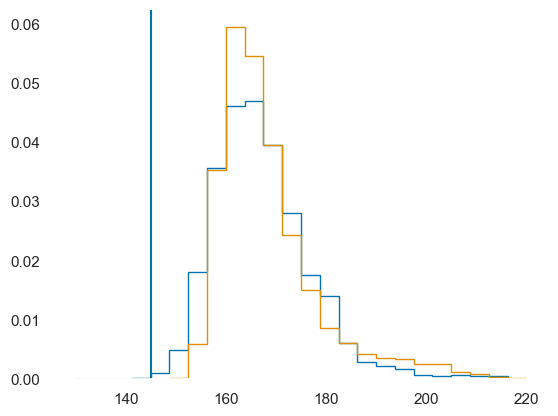

In [22]:
mu0 = (eli_forced["eli_05"]).isel(year=0).groupby("time.month").mean().sel(month=1)
scale = dTdx_scale.isel(year=0, month=0) / Th_scale["eli_05"]
eli_anom_sim = sel_(stoc0[varnames[0]]) / scale
eli_anom_true = sel_(Th_rolling[V0].sel(year=Y0)) / scale

eli_full_sim = eli_anom_sim + mu0
eli_full_true = eli_anom_true + mu0

bins_ = np.linspace(130, 220, 25)
pdf0_, _ = src.utils.get_empirical_pdf(eli_full_sim, bins_)
pdf1_, _ = src.utils.get_empirical_pdf(eli_full_true, bins_)


plt.stairs(pdf0_, bins_)
plt.stairs(pdf1_, bins_)
plt.axvline(145)

In [23]:
dTdx_scale.isel(year=0)

<xarray.DataArray 'sst' (month: 12)> Size: 96B
array([0.9758921 , 0.78289672, 0.66923466, 0.6510619 , 0.78204604,
       0.92184878, 1.03054137, 1.18274548, 1.29495347, 1.30300211,
       1.24948286, 1.15629451])
Coordinates:
    year     int64 8B 1871
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [24]:
eli_forced["eli_05"].isel(year=0).groupby("time.month").mean().min()

<xarray.DataArray 'eli_05' ()> Size: 8B
array(165.18387397)
Coordinates:
    year     int64 8B 1871
Attributes:
    long_name:     Potential Temperature
    units:         degC
    grid_loc:      3111
    cell_methods:  time: mean

In [25]:
(
    eli_forced["eli_05"].isel(year=0)
    + Th_rolling["eli_05"].isel(year=0) * Th_scale["eli_05"]
).min()

<xarray.DataArray 'eli_05' ()> Size: 8B
array(146.08333333)
Coordinates:
    year     int64 8B 1871
Attributes:
    long_name:     Potential Temperature
    units:         degC
    grid_loc:      3111
    cell_methods:  time: mean

In [26]:
eli_forced["eli_05"].isel(year=0).mean()

<xarray.DataArray 'eli_05' ()> Size: 8B
array(170.57591186)
Coordinates:
    year     int64 8B 1871
Attributes:
    long_name:     Potential Temperature
    units:         degC
    grid_loc:      3111
    cell_methods:  time: mean

In [27]:
Th_rolling.isel(year=0)[varnames[0]].min()

<xarray.DataArray 'eli_05_scaled_median' ()> Size: 8B
array(-2.04758796)
Coordinates:
    year     int64 8B 1871
Attributes:
    long_name:     Potential Temperature
    units:         degC
    grid_loc:      3111
    cell_methods:  time: mean